In [10]:
"""
Agricultural Insurance Loss Prediction Pipeline
Complete end-to-end workflow for training and generating predictions
"""

from typing import Dict, List
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


In [11]:

class XGBoostInsuranceModel:
    """
    XGBoost model optimized for agricultural insurance loss prediction
    Two-stage approach: classification + regression
    """
    
    def __init__(self, model_type='two_stage'):
        self.model_type = model_type
        self.classifier = None
        self.regressor = None
        self.feature_importance = None
        
    def get_xgb_params(self, task='classification', imbalanced=True) -> Dict:
        base_params = {
            'n_estimators': 500,
            'learning_rate': 0.05,
            'max_depth': 6,
            'min_child_weight': 3,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'gamma': 0.1,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'random_state': 42,
            'n_jobs': -1,
            'tree_method': 'hist',
        }
        
        if task == 'classification':
            params = {
                **base_params,
                'objective': 'binary:logistic',
                'eval_metric': 'auc',
            }
            if imbalanced:
                params['scale_pos_weight'] = 1
        else:
            params = {
                **base_params,
                'objective': 'reg:squarederror',
                'eval_metric': 'rmse',
                'max_depth': 7,
            }
        
        return params
    
    def fit(self, X: np.ndarray, y: np.ndarray, 
            X_val: np.ndarray = None, y_val: np.ndarray = None):
        if self.model_type == 'two_stage':
            # Stage 1: Binary classification (loss vs no loss)
            y_binary = (y > 0).astype(int)
            scale_pos_weight = (y_binary == 0).sum() / np.maximum((y_binary == 1).sum(), 1)
            
            clf_params = self.get_xgb_params('classification', imbalanced=True)
            clf_params['scale_pos_weight'] = scale_pos_weight
            
            self.classifier = xgb.XGBClassifier(**clf_params)
            
            if X_val is not None:
                y_val_binary = (y_val > 0).astype(int)
                self.classifier.fit(
                    X, y_binary,
                    eval_set=[(X_val, y_val_binary)],
                    verbose=False
                )
            else:
                self.classifier.fit(X, y_binary, verbose=False)
            
            # Stage 2: Regression on non-zero losses
            nonzero_mask = y > 0
            
            if nonzero_mask.sum() > 10:
                reg_params = self.get_xgb_params('regression')
                self.regressor = xgb.XGBRegressor(**reg_params)
                
                if X_val is not None:
                    nonzero_val_mask = y_val > 0
                    if nonzero_val_mask.sum() > 0:
                        self.regressor.fit(
                            X[nonzero_mask], y[nonzero_mask],
                            eval_set=[(X_val[nonzero_val_mask], y_val[nonzero_val_mask])],
                            verbose=False
                        )
                    else:
                        self.regressor.fit(X[nonzero_mask], y[nonzero_mask], verbose=False)
                else:
                    self.regressor.fit(X[nonzero_mask], y[nonzero_mask], verbose=False)
        
        else:
            reg_params = self.get_xgb_params('regression')
            self.regressor = xgb.XGBRegressor(**reg_params)
            
            if X_val is not None:
                self.regressor.fit(
                    X, y,
                    eval_set=[(X_val, y_val)],
                    verbose=False
                )
            else:
                self.regressor.fit(X, y, verbose=False)
        
        return self
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.model_type == 'two_stage':
            loss_prob = self.classifier.predict_proba(X)[:, 1]
            
            if self.regressor is not None:
                loss_amount = self.regressor.predict(X)
                loss_amount = np.maximum(loss_amount, 0)
            else:
                loss_amount = np.zeros(len(X))
            
            predictions = np.where(loss_prob > 0.5, loss_amount, 0)
            return predictions
        else:
            predictions = self.regressor.predict(X)
            return np.maximum(predictions, 0)
    
    def get_feature_importance(self, X: np.ndarray, y: np.ndarray, 
                              feature_names: List[str]) -> pd.DataFrame:
        importance_df = pd.DataFrame({'feature': feature_names})
        
        if self.model_type == 'two_stage' and self.classifier is not None:
            clf_importance = self.classifier.feature_importances_
            importance_df['clf_gain'] = clf_importance
        
        if self.regressor is not None:
            reg_importance = self.regressor.feature_importances_
            importance_df['reg_gain'] = reg_importance
        
        return importance_df.sort_values('reg_gain', ascending=False)



In [12]:

class InsuranceModelEvaluator:
    """Comprehensive evaluation for insurance models"""
    
    @staticmethod
    def calculate_metrics(y_true: np.ndarray, 
                         y_pred: np.ndarray,
                         y_prob: np.ndarray = None) -> Dict[str, float]:
        metrics = {}
        
        # Classification metrics
        y_true_binary = (y_true > 0).astype(int)
        y_pred_binary = (y_pred > 0).astype(int)
        
        metrics['accuracy'] = accuracy_score(y_true_binary, y_pred_binary)
        metrics['f1_score'] = f1_score(y_true_binary, y_pred_binary, zero_division=0)
        
        if y_prob is not None:
            metrics['auc_roc'] = roc_auc_score(y_true_binary, y_prob)
            metrics['avg_precision'] = average_precision_score(y_true_binary, y_prob)
        
        # Regression metrics
        metrics['rmse'] = np.sqrt(mean_squared_error(y_true, y_pred))
        metrics['mae'] = mean_absolute_error(y_true, y_pred)
        metrics['r2'] = r2_score(y_true, y_pred)
        
        nonzero_mask = y_true > 0
        if nonzero_mask.sum() > 0:
            metrics['rmse_nonzero'] = np.sqrt(
                mean_squared_error(y_true[nonzero_mask], y_pred[nonzero_mask])
            )
            metrics['mae_nonzero'] = mean_absolute_error(
                y_true[nonzero_mask], y_pred[nonzero_mask]
            )
        
        # Actuarial metrics
        total_actual = y_true.sum()
        total_predicted = y_pred.sum()
        metrics['loss_ratio'] = total_predicted / np.maximum(total_actual, 1)
        
        mape_mask = y_true > 0
        if mape_mask.sum() > 0:
            metrics['mape'] = np.mean(
                np.abs((y_true[mape_mask] - y_pred[mape_mask]) / y_true[mape_mask])
            ) * 100
        
        errors = np.abs(y_true - y_pred)
        metrics['q90_error'] = np.percentile(errors, 90)
        metrics['q95_error'] = np.percentile(errors, 95)
        
        return metrics
    
    @staticmethod
    def plot_results(y_true, y_pred, save_path=None):
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Predicted vs Actual
        axes[0, 0].scatter(y_true, y_pred, alpha=0.5)
        axes[0, 0].plot([y_true.min(), y_true.max()], 
                       [y_true.min(), y_true.max()], 'r--')
        axes[0, 0].set_xlabel('Actual Loss')
        axes[0, 0].set_ylabel('Predicted Loss')
        axes[0, 0].set_title('Predicted vs Actual')
        
        # Residuals
        residuals = y_true - y_pred
        axes[0, 1].scatter(y_pred, residuals, alpha=0.5)
        axes[0, 1].axhline(y=0, color='r', linestyle='--')
        axes[0, 1].set_xlabel('Predicted Loss')
        axes[0, 1].set_ylabel('Residuals')
        axes[0, 1].set_title('Residual Plot')
        
        # Distribution comparison
        axes[1, 0].hist(y_true[y_true > 0], bins=50, alpha=0.5, label='Actual')
        axes[1, 0].hist(y_pred[y_pred > 0], bins=50, alpha=0.5, label='Predicted')
        axes[1, 0].set_xlabel('Loss Amount (non-zero)')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Loss Distribution')
        axes[1, 0].legend()
        
        # Cumulative losses
        axes[1, 1].plot(np.cumsum(y_true), label='Actual Cumulative')
        axes[1, 1].plot(np.cumsum(y_pred), label='Predicted Cumulative')
        axes[1, 1].set_xlabel('Sample Index')
        axes[1, 1].set_ylabel('Cumulative Loss')
        axes[1, 1].set_title('Cumulative Losses')
        axes[1, 1].legend()
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()



In [13]:
def main_pipeline():
    """Main prediction pipeline"""
    
    print("AGRICULTURAL INSURANCE LOSS PREDICTION PIPELINE")
    
    # Load data
    print("\n Loading merged weather + insurance dataset (with lagged feature if available)")
    try:
        # Prefer the augmented file if it exists
        aug_path = r"C:\\Users\\Arnold\\OneDrive\\Desktop\\CAPSTONE PROJECT\\farming_risk_regions\\data\\processed\\merged_weather_insurance_data_with_lag.csv"
        base_path = r"C:\\Users\\Arnold\\OneDrive\\Desktop\\CAPSTONE PROJECT\\farming_risk_regions\\data\\processed\\merged_weather_insurance_data.csv"
        import os
        if os.path.exists(aug_path):
            merged_df = pd.read_csv(aug_path)
            print(f"  Loaded augmented dataset with lag: {aug_path}")
        else:
            merged_df = pd.read_csv(base_path)
            print(f"  Loaded base dataset: {base_path}")

        print(f"  Loaded {len(merged_df)} samples")
        print(f"  Shape: {merged_df.shape}")
        print(f"  Columns: {list(merged_df.columns[:10])}... ({len(merged_df.columns)} total)")
    except FileNotFoundError:
        print("  Merged dataset not found.")
        print("  Expected path: data/processed/merged_weather_insurance_data*.csv")
        print("  Please run preprocessing_am-01.ipynb first.")
        raise

    # Data exploration
    print("\nData exploration")
    print(f"  Loss column present: {'loss' in merged_df.columns}")
    if 'loss' in merged_df.columns:
        print(f"  Zero losses: {(merged_df['loss'] == 0).sum()} ({(merged_df['loss'] == 0).mean()*100:.1f}%)")
        print(f"  Non-zero losses: {(merged_df['loss'] > 0).sum()} ({(merged_df['loss'] > 0).mean()*100:.1f}%)")
        print(f"  Mean loss: {merged_df['loss'].mean():.6f}")
        print(f"  Std loss: {merged_df['loss'].std():.6f}")
    
    # Train/test split
    print("\nTrain/test split (80/20 temporal)")
    merged_df = merged_df.sort_values(['year', 'month']).reset_index(drop=True)
    
    split_idx = int(len(merged_df) * 0.8)
    train_df = merged_df.iloc[:split_idx]
    test_df = merged_df.iloc[split_idx:]
    
    # Feature columns
    # IMPORTANT: exclude 'loss_ratio' because it duplicates the target and causes data leakage
    # We allow 'loss_ratio_lag1' (if present) as a safe historical predictor
    exclude = ['loss', 'loss_ratio', 'year', 'month', 'date', 'join_key', 'location', 'county_state', 'commodity_year']
    feature_cols = [col for col in merged_df.columns if col not in exclude]
    
    print(f"  Using {len(feature_cols)} features (sample): {feature_cols[:10]}")

    X_train = train_df[feature_cols].fillna(0).values
    y_train = train_df['loss'].fillna(0).values
    X_test = test_df[feature_cols].fillna(0).values
    y_test = test_df['loss'].fillna(0).values
    
    print(f"  Train set: {len(X_train)} samples, {X_train.shape[1]} features")
    print(f"  Test set: {len(X_test)} samples")

    # Hyperparameter Tuning
    print("\nPerforming Hyperparameter Tuning with GridSearchCV")
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Tuning for Classifier
    print("  Tuning Classifier...")
    y_train_binary = (y_train > 0).astype(int)
    clf_param_grid = {
        'max_depth': [5, 7],
        'learning_rate': [0.05, 0.1],
        'n_estimators': [500, 1000],
    }
    
    initial_clf = xgb.XGBClassifier(**XGBoostInsuranceModel().get_xgb_params('classification'))
    grid_search_clf = GridSearchCV(initial_clf, clf_param_grid, cv=tscv, scoring='roc_auc', n_jobs=-1, verbose=1)
    grid_search_clf.fit(X_train, y_train_binary)
    print(f"  Best Classifier Params: {grid_search_clf.best_params_}")
    
    # Tuning for Regressor
    print("\n  Tuning Regressor...")
    nonzero_mask_train = y_train > 0
    reg_param_grid = {
        'max_depth': [5, 7],
        'learning_rate': [0.05, 0.1],
        'n_estimators': [500, 1000],
    }
    
    initial_reg = xgb.XGBRegressor(**XGBoostInsuranceModel().get_xgb_params('regression'))
    grid_search_reg = GridSearchCV(initial_reg, reg_param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
    grid_search_reg.fit(X_train[nonzero_mask_train], y_train[nonzero_mask_train])
    print(f"  Best Regressor Params: {grid_search_reg.best_params_}")

    # Train model with best parameters
    print("\nTraining two-stage XGBoost model with best parameters")
    
    model = XGBoostInsuranceModel(model_type='two_stage')
    # Update model to use best params
    model.classifier = grid_search_clf.best_estimator_
    model.regressor = grid_search_reg.best_estimator_
    
    # Predictions
    print("\nGenerating predictions")
    y_pred = model.predict(X_test)
    
    if model.classifier is not None:
        try:
            y_prob = model.classifier.predict_proba(X_test)[:, 1]
        except Exception:
            y_prob = None
    else:
        y_prob = None
    
    print(f"  Predictions generated for {len(y_pred)} test samples")
    print(f"  Predicted loss range: [{y_pred.min():.6f}, {y_pred.max():.6f}]")
    
    # Evaluate
    print("\nModel evaluation")
    evaluator = InsuranceModelEvaluator()
    metrics = evaluator.calculate_metrics(y_test, y_pred, y_prob)
    
    print("\n  Test Set Performance Metrics:")
    print("  " + "-" * 50)
    for metric, value in sorted(metrics.items()):
        print(f"    {metric:25s}: {value:10.4f}")
    
    # Feature importance
    print("\nFeature importance analysis")
    try:
        importance_df = model.get_feature_importance(X_test, y_test, feature_cols)
        print("\n  Top 10 Most Important Features:")
        for idx, row in importance_df.head(10).iterrows():
            print(f"    {row['feature']:35s}: {row.get('reg_gain', 0):8.4f}")
    except Exception as e:
        print(f"  Feature importance skipped: {e}")

    # SHAP Interpretability
    print("\nGenerating SHAP plots for model interpretability")
    import shap
    
    # SHAP for Classifier
    try:
        print("  Generating SHAP summary plot for Classifier...")
        explainer_clf = shap.TreeExplainer(model.classifier)
        shap_values_clf = explainer_clf.shap_values(X_test)
        shap.summary_plot(shap_values_clf, X_test, feature_names=feature_cols, show=False)
        plt.title("SHAP Summary Plot - Classifier (Loss Occurrence)")
        plt.show()
    except Exception as e:
        print(f"  SHAP plot for classifier skipped: {e}")

    # SHAP for Regressor
    try:
        print("  Generating SHAP summary plot for Regressor...")
        explainer_reg = shap.TreeExplainer(model.regressor)
        shap_values_reg = explainer_reg.shap_values(X_test)
        shap.summary_plot(shap_values_reg, X_test, feature_names=feature_cols, show=False)
        plt.title("SHAP Summary Plot - Regressor (Loss Amount)")
        plt.show()
    except Exception as e:
        print(f"  SHAP plot for regressor skipped: {e}")

    # Save predictions (include location/time columns)
    meta_cols = []
    for c in ['location', 'county_state', 'year', 'month', 'commodity_year', 'date', 'join_key']:
        if c in test_df.columns:
            meta_cols.append(c)
    preds_meta = test_df.reset_index(drop=True)[meta_cols].copy()
    preds_meta['actual_loss'] = y_test
    preds_meta['predicted_loss'] = y_pred
    preds_meta['loss_probability'] = y_prob if y_prob is not None else np.zeros(len(y_pred))
    preds_meta['residual'] = preds_meta['actual_loss'] - preds_meta['predicted_loss']
    preds_meta['abs_error'] = np.abs(preds_meta['residual'])
    
    pred_output_path = "C:\\Users\\Arnold\\OneDrive\\Desktop\\CAPSTONE PROJECT\\farming_risk_regions\\data\\processed\\model_predictions.csv"
    preds_meta.to_csv(pred_output_path, index=False)
    print(f"  Saved predictions to: {pred_output_path}")

    # Additional insights and diagnostics unchanged

    try:
        evaluator.plot_results(y_test, y_pred, save_path='model_diagnostics.png')
        print("  Saved diagnostic plots to: model_diagnostics.png")
    except Exception as e:
        print(f"  Plot generation skipped: {e}")

    print(f"\nResults saved to:")
    print(f"  • Predictions: {pred_output_path}")
    print(f"  • Diagnostics: model_diagnostics.png")
    
    return model, metrics, preds_meta


AGRICULTURAL INSURANCE LOSS PREDICTION PIPELINE

 Loading merged weather + insurance dataset (with lagged feature if available)
  Loaded augmented dataset with lag: C:\\Users\\Arnold\\OneDrive\\Desktop\\CAPSTONE PROJECT\\farming_risk_regions\\data\\processed\\merged_weather_insurance_data_with_lag.csv
  Loaded 19811 samples
  Shape: (19811, 123)
  Columns: ['location', 'year', 'month', 'ppt_total', 'rainy_days', 'ppt_variance', 'tmax', 'tmin', 'temp_range', 'tmax30']... (123 total)

Data exploration
  Loss column present: True
  Zero losses: 11160 (56.3%)
  Non-zero losses: 8651 (43.7%)
  Mean loss: 0.663972
  Std loss: 3.419066

Train/test split (80/20 temporal)
  Using 115 features (sample): ['ppt_total', 'rainy_days', 'ppt_variance', 'tmax', 'tmin', 'temp_range', 'tmax30', 'tmax35', 'tmin0', 'gdd']
  Train set: 15848 samples, 115 features
  Test set: 3963 samples

Performing Hyperparameter Tuning with GridSearchCV
  Tuning Classifier...
Fitting 5 folds for each of 8 candidates, tota

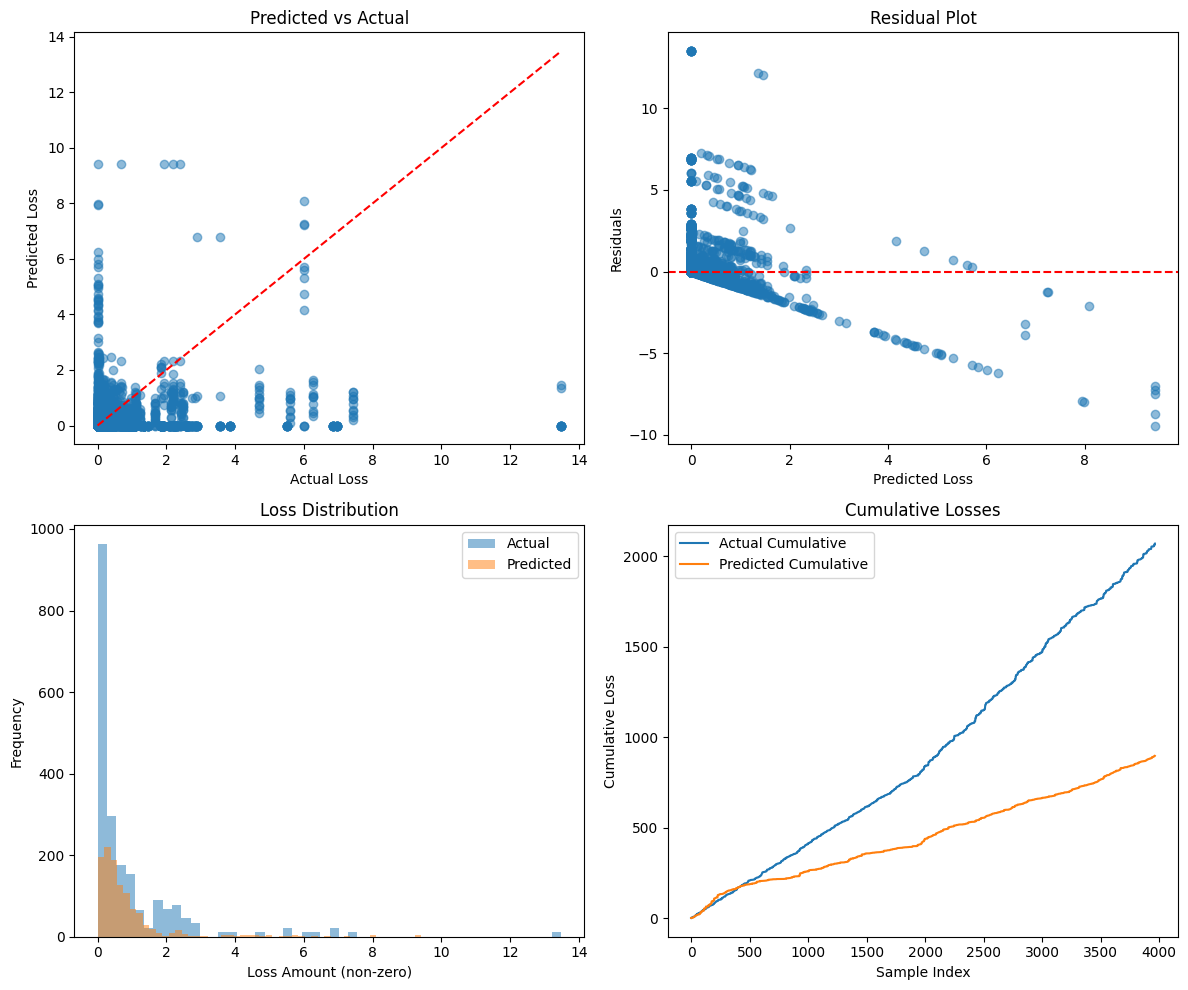

  Saved diagnostic plots to: model_diagnostics.png

Results saved to:
  • Predictions: C:\Users\Arnold\OneDrive\Desktop\CAPSTONE PROJECT\farming_risk_regions\data\processed\model_predictions.csv
  • Diagnostics: model_diagnostics.png


In [14]:

if __name__ == "__main__":
    model, metrics, predictions = main_pipeline()